In [4]:
poo = 0
print(poo)
poo = poo + 1
import jax

import jax
jax.config.update("jax_enable_x64", True)

import sys
sys.path.append("../../gigalens/src")

print(poo)
poo = poo + 1
from gigalens.jax.scene import Component, Plane, LensModel
from gigalens.jax.scene_simulator import SceneSimulator
from gigalens.jax.scene_prob_model import ImageData, ProbModel
from gigalens.jax.experimental.adaptive_supersample import AdaptiveImageData
from gigalens.jax.inference import ModellingSequence
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles import mass, light
from gigalens.jax.cosmo import wCDM_Cosmo
from gigalens.jax.scene import shared
print(poo)
poo = poo + 1
import tensorflow_probability.substrates.jax as tfp
from jax import numpy as jnp
from matplotlib import pyplot as plt
import time
import numpy as np
import optax
from datetime import datetime
tfd = tfp.distributions
print(poo)
poo = poo + 1
from gigalens.jax.grouped_priors import DiskEllipticity

lhalo = Component(mass.nfw.NFW_ELLIPSE_EINSTEIN(),
               dict(
                   theta_E = tfd.Normal(13., 0.5),
                   Rs = tfd.Uniform(20,100),
                   e1 = tfd.TruncatedNormal(0, 0.05, -0.2, 0.2),
                   e2 = tfd.TruncatedNormal(0, 0.05, -0.2, 0.2),
                   center_x = tfd.Normal(5.1, 0.05),
                   center_y = tfd.Normal(3.8, 0.05)
               )
)

ld = Component(mass.piemd.DPIE(),
                dict(
                    theta_E = tfd.TruncatedNormal(1.6, 0.1, 1.0, 2.5),
                    r_core = 0.05,
                    r_cut = tfd.Uniform(0.2,20),
                    e1 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                    e2 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                    center_x = tfd.Normal(11.7, 0.1),
                    center_y = tfd.Normal(23.3, 0.1)
                )           
)

le = Component(mass.epl.EPL(),
                   dict(
                       theta_E = tfd.TruncatedNormal(2.4, 0.1, 1, 3),
                       gamma = tfd.Uniform(1,3),
                       e1 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                       e2 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                       center_x = tfd.Normal(-22.0, 0.1),
                       center_y = tfd.Normal(-25.4, 0.1)
                   )
)

lf = Component(mass.piemd.DPIE(),
                   dict(
                       theta_E = tfd.TruncatedNormal(0.8151327, 0.05, 0.5, 1.5),
                       r_core = 0.05,
                       r_cut = tfd.Uniform(0.2,20),
                       center_x = tfd.Normal(-14.0, 0.1),
                       center_y = tfd.Normal(-5.3, 0.1),
                       e1 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                       e2 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                   )
)

shear_model = Component(mass.shear.Shear(),
                    dict(
                        gamma1 = tfd.Normal(0., 0.05),
                        gamma2 = tfd.Normal(0., 0.05),
                    ))

e1_shared_1 = shared(tfd.TruncatedNormal(0, 0.1, -0.5, 0.5))
e2_shared_1 = shared(tfd.TruncatedNormal(0, 0.1, -0.5, 0.5))
x_shared_1 = shared(tfd.Normal(6.1, 0.3))
y_shared_1 = shared(tfd.Normal(2.8, 0.3))
scale_1 = shared(tfd.LogNormal(jnp.log(0.1), 0.2))

source1_light = Component(
        light.sersic.SersicEllipse(use_lstsq=True),
        dict(
            # z_source = 0.962,
            center_x = x_shared_1,
            center_y = y_shared_1,
            R_sersic = scale_1,
            n_sersic = tfd.Uniform(0.1,15),
            e1 = e1_shared_1,
            e2 = e2_shared_1,
        )
)

source1_light_details = Component(
        light.elliptical_shapelets.EllipticalShapelets(6, use_lstsq=True),
        dict(
            # z_source = 0.962,
            center_x = x_shared_1,
            center_y = y_shared_1,
            beta = scale_1,
            e1 = e1_shared_1,
            e2 = e2_shared_1,
        )
)

source2_light = Component(
        light.sersic.SersicEllipse(use_lstsq=True),
        dict(
            # z_source = 0.962,
            center_x = tfd.Normal(10.4, 0.3),
            center_y = tfd.Normal(3.8, 0.3),
            R_sersic = tfd.LogNormal(jnp.log(0.1), 0.2),
            n_sersic = tfd.Uniform(0.1,15),
            e1 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
            e2 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
        )
)

e1_shared_3 = shared(tfd.TruncatedNormal(0, 0.1, -0.5, 0.5))
e2_shared_3 = shared(tfd.TruncatedNormal(0, 0.1, -0.5, 0.5))
x_shared_3 = shared(tfd.Normal(5.9, 0.3))
y_shared_3 = shared(tfd.Normal(7.0, 0.3))
scale_3 = shared(tfd.LogNormal(jnp.log(0.1), 0.2))

source3_light = Component(
        light.sersic.SersicEllipse(use_lstsq=True),
        dict(
            # z_source = 1.166,
            center_x = x_shared_3,
            center_y = y_shared_3,
            R_sersic = tfd.LogNormal(jnp.log(0.1), 0.2),
            n_sersic = tfd.Uniform(0.1,4),
            e1 = e1_shared_3,
            e2 = e2_shared_3,
        )
)

source3_light_details = Component(
        light.elliptical_shapelets.EllipticalShapelets(6, use_lstsq=True),
        dict(
            # z_source = 1.166,
            center_x = x_shared_3,
            center_y = y_shared_3,
            beta = tfd.LogNormal(jnp.log(0.1), 0.2),
            e1 = e1_shared_3,
            e2 = e2_shared_3,
        )
)

e1_shared_4 = shared(tfd.TruncatedNormal(0, 0.1, -0.5, 0.5))
e2_shared_4 = shared(tfd.TruncatedNormal(0, 0.1, -0.5, 0.5))
x_shared_4 = shared(tfd.Normal(3.7, 0.3))
y_shared_4 = shared(tfd.Normal(3.2, 0.3))
scale_4 = shared(tfd.LogNormal(jnp.log(0.1), 0.2))

source4_light = Component(
        light.sersic.SersicEllipse(use_lstsq=True),
        dict(
            # z_source = 1.432,
            center_x = x_shared_4,
            center_y = y_shared_4,
            R_sersic = scale_4,
            n_sersic = tfd.Uniform(0.1,15),
            e1 = e1_shared_4,
            e2 = e2_shared_4,
        )
)

source4_light_details = Component(
        light.elliptical_shapelets.EllipticalShapelets(6, use_lstsq=True),
        dict(
            # z_source = 1.432,
            center_x = x_shared_4,
            center_y = y_shared_4,
            beta = scale_4,
            e1 = e1_shared_4,
            e2 = e2_shared_4,
        )
)

source5_light = Component(
        light.sersic.SersicEllipse(use_lstsq=True),
        dict(
            # z_source = 1.432,
            center_x = tfd.Normal(4.0, 0.3),
            center_y = tfd.Normal(0.6, 0.3),
            R_sersic = tfd.LogNormal(jnp.log(0.1), 0.2),
            n_sersic = tfd.Uniform(0.1,15),
            e1 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
            e2 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
        )
)

source9_light = Component(
        light.sersic.SersicEllipse(use_lstsq=True),
        dict(
            # z_source = 1.506,
            center_x = tfd.Normal(-8.9, 0.3),
            center_y = tfd.Normal(-13.8, 0.3),
            R_sersic = tfd.LogNormal(jnp.log(0.1), 0.15),
            n_sersic = tfd.Uniform(0.1,15),
            e1 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
            e2 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
        )
)

source7_light = Component(
        light.sersic.SersicEllipse(use_lstsq=True),
        dict(
            # z_source = 1.627,
            center_x = tfd.Normal(3.5, 0.3),
            center_y = tfd.Normal(0.7, 0.3),
            R_sersic = tfd.LogNormal(jnp.log(0.1), 0.2),
            n_sersic = tfd.Uniform(0.1,4),
            e1 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
            e2 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
        )
)

source6_light = Component(
        light.sersic.SersicEllipse(use_lstsq=True),
        dict(
            # z_source = 1.656,
            center_x = tfd.Normal(2.8, 0.3),
            center_y = tfd.Normal(3.1, 0.3),
            R_sersic = tfd.LogNormal(jnp.log(0.1), 0.2),
            n_sersic = tfd.Uniform(0.1,4),
            e1 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
            e2 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
        )
)

e1_shared_12 = shared(tfd.TruncatedNormal(0, 0.1, -0.5, 0.5))
e2_shared_12 = shared(tfd.TruncatedNormal(0, 0.1, -0.5, 0.5))
x_shared_12 = shared(tfd.Normal(1.2, 0.3))
y_shared_12 = shared(tfd.Normal(4.4, 0.3))
scale_12 = shared(tfd.LogNormal(jnp.log(0.1), 0.2))

source12_light = Component(
        light.sersic.SersicEllipse(use_lstsq=True),
        dict(
            # z_source = 3.086,
            center_x = x_shared_12,
            center_y = y_shared_12,
            R_sersic = scale_12,
            n_sersic = tfd.Uniform(0.1,15),
            e1 = e1_shared_12,
            e2 = e2_shared_12,
        )
)

source12_light_details = Component(
        light.elliptical_shapelets.EllipticalShapelets(6, use_lstsq=True),
        dict(
            # z_source = 3.086,
            center_x = x_shared_12,
            center_y = y_shared_12,
            beta = scale_12,
            e1 = e1_shared_12,
            e2 = e2_shared_12,
        )
)

source13_light = Component(
        light.sersic.SersicEllipse(use_lstsq=True),
        dict(
            # z_source = 3.086,
            center_x = tfd.Normal(5.7,0.3),
            center_y = tfd.Normal(6.1,0.3),
            R_sersic = tfd.LogNormal(jnp.log(0.1), 0.2),
            n_sersic = tfd.Uniform(0.1,15),
            e1 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
            e2 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5)
        )
)

source8_light = None

source11_light = Component(
        light.sersic.SersicEllipse(use_lstsq=True),
        dict(
            # z_source = 4.090,
            center_x = tfd.Normal(3.,0.5),
            center_y = tfd.Normal(1.5,0.5),
            R_sersic = tfd.LogNormal(jnp.log(0.1), 0.2),
            n_sersic = tfd.Uniform(0.1,15),
            e1 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
            e2 = tfd.TruncatedNormal(0, 0.1, -0.5, 0.5)
        )
)

cosmo_model = wCDM_Cosmo(z_lens=0.49, z_source_ref=1.432)
cosmo = Component(cosmo_model,
    dict(
        H0=70.,
        Om0=0.3,
        w0=-1,
        # wa=0.0,
        k=0.0,
    )
)

lens_plane = Plane(redshift=0.49, mass=[lhalo, ld, le, lf, shear_model])
source1_2 = Plane(redshift=0.962, light=[source1_light, source1_light_details, source2_light])
source3 = Plane(redshift=1.166, light=[source3_light, source3_light_details])
source4_5 = Plane(redshift=1.432, light=[source4_light, source5_light])
source6 = Plane(redshift=1.656, light=[source6_light])
source7 = Plane(redshift=1.627, light=[source7_light])
source9 = Plane(redshift=1.506, light=[source9_light])
source12_13 = Plane(redshift=3.086, light=[source12_light, source12_light_details, source13_light])
source11 = Plane(redshift=4.090, light=[source11_light])
print(poo)
poo = poo + 1
# import boiler as boiler
numPix, deltaPix = 300, 0.2
# observed_images = boiler.observed_images()
# error_maps = boiler.error_maps()
# masks = boiler.masks()
# psfs = boiler.psf()

indices = (0,1,2,3,4,5,6,8)

model = LensModel(
        planes=[lens_plane, source1_2, source3, source4_5, source9, source7, source6, source12_13, source11],
        cosmo=cosmo
)
print(poo)
poo = poo + 1
sees = [[source1_light, source1_light_details, source2_light], [source3_light, source3_light_details], [source4_light, source5_light], [source9_light], [source7_light], [source6_light], [source12_light, source12_light_details, source13_light], [source8_light], [source11_light]]

supersamples = [1, 1, 1, 1, 2, 2, 2, 1, 2]

datasets = [ImageData(np.ones((300,300)), 
                      SimulatorConfig(
                          delta_pix=deltaPix,
                          num_pix=numPix,
                          kernel=None,
                          supersample=supersamples[i],
                          likelihood_precision='float64'),
                      mask=None,
                      error_map=np.ones((300,300)),
                      sees=sees[i]) for i in indices]
print(poo)
poo = poo + 1
prob_model = ProbModel(model, datasets, mode='lstsq')
model_seq = ModellingSequence(prob_model)
print(poo)
poo = poo + 1

0
1
2
3
4


/tmp/ipykernel_97290/4108370633.py:337: UserWarning: [plausibility] EPL[plane 0 mass 2].gamma: prior mass outside plausible band [1.1, 3]: estimated mass 0.05 (exact (cdf)) exceeds 0.05 — the Tessore & Metcalf (2015) angular series is valid for slope t=gamma-1 in (0,2); the recurrence prefactor -f*(2n-(2-t))/(2n+(2-t)) has poles at gamma=2n+3 (gamma=5 verified NaN 2026-07-10), and outside (1,3) the fixed-niter series is not a convergent representation. gamma<=1 is a non-lensing (non-convergent total mass) slope; gamma>=3 has a non-integrable center. Soft band gamma>=1.1: slopes just above 1 are unlikely, and in some cases inferencer can be biased toward them — a plausibility prompt, not a hard bound. Physically valid but atypical; check this is intended.
  model = LensModel(


5
6
7


Prob model accidentally does not have the source4_light_details Component, whereas the best_nb.npy file was created from a MAP run with source4_light_details included in the model.

When I load in best and biject it forward, the details Component silently disappears. If I were to change the prob model defined above to include source4_light_details, then the biject would return the correct parameters.\

In [5]:
best = np.load("best_nb.npy")
# qz = jnp.load("qz.npz")
# best = qz['loc']
# samples = np.load("mclmc_samples.npy")
# num_chains, num_samples, num_params = len(samples), len(samples[0]), len(samples[0,0])
# best = np.median(samples.reshape(-1, num_params), axis=0)

params = prob_model.bij.forward(best)
params = model.to_params(params)
params = jax.tree.map(lambda x: float(np.squeeze(np.array(x, dtype=np.float64))), params)
mass_params = params['planes'][0]['mass']

In [10]:
prob_model.unconstrained(prob_model.constrained(best)).shape

(93,)

In [7]:
best.shape

(93,)

In [6]:
params

{'cosmo': {'H0': 70.0, 'Om0': 0.3, 'k': 0.0, 'w0': -1.0},
 'planes': {0: {'geometry': {'redshift': 0.49},
   'mass': {0: {'Rs': 46.56123294323542,
     'center_x': 5.294141285067036,
     'center_y': 3.893140161550867,
     'e1': -0.040363085695230005,
     'e2': 0.029489771389071356,
     'theta_E': 13.372331218494981},
    1: {'center_x': 10.444643319854611,
     'center_y': 22.917126434324437,
     'e1': -0.21396003749563947,
     'e2': 0.31809290713755023,
     'r_core': 0.05,
     'r_cut': 2.256849964783179,
     'theta_E': 1.9557655101743499},
    2: {'center_x': -21.720698175930497,
     'center_y': -25.11749300208033,
     'e1': 0.266261619181175,
     'e2': 0.2447022343893524,
     'gamma': 2.2478891483512102,
     'theta_E': 2.382185980502115},
    3: {'center_x': -14.327225659888205,
     'center_y': -5.977388252085507,
     'e1': -0.38375937622258244,
     'e2': -0.419471248253927,
     'r_core': 0.05,
     'r_cut': 13.635273499425612,
     'theta_E': 0.5630400316912366},
 

In [15]:
def scalebar(ax, x=20, y=-25, color='w'):
    ax.plot([x,x+5],[y,y],linewidth=2,color=color)
    ax.text(x+2.5,y+2.2,'5"',fontsize=14,color=color,ha='center',va='center')
def scalebar2(ax, x=20, y=-25, color='w'):
    ax.plot([x,x+1],[y,y],linewidth=2,color=color)
    ax.text(x+0.5,y+0.5,'1"',fontsize=14,color=color,ha='center',va='center')

In [16]:
def plot_PAs(ax, length=0.5, c='red'):
    points = np.zeros((len(mass_params) - 1,2))
    angles = np.zeros(len(mass_params) - 1)
    for i, key in enumerate(mass_params.keys()):
        try:
            points[i] = [mass_params[key]['center_x'], mass_params[key]['center_y']]
            q, phi = boiler.convertEllipticity(mass_params[key]['e1'], mass_params[key]['e1'])
            angles[i] = phi
        except:
            pass
    U = length * np.cos(angles)
    V = length * np.sin(angles)
    X = points[:, 0]
    Y = points[:, 1]
    ax.quiver(X, Y, U, V, angles='xy', scale_units='xy', scale=1, color=c)

def src_scale(ax, i):
    match i:
        case 0:
            ax.set_xlim(2,14)
            ax.set_ylim(-2,10)
            scalebar2(ax, x=12, y=-1)
        case 1:
            ax.set_xlim(-2,10)
            ax.set_ylim(-2,10)
            scalebar2(ax, x=8, y=-1)
        case 2:
            ax.set_xlim(-2,10)
            ax.set_ylim(-2,10)
            scalebar2(ax, x=8, y=-1)
        case 3:
            ax.set_xlim(-15,-5)
            ax.set_ylim(-20,-10)
            scalebar2(ax, x=-7, y=-19)
        case 4:
            ax.set_xlim(-2,10)
            ax.set_ylim(-2,10)
            scalebar2(ax, x=8, y=-1)
        case 5:
            ax.set_xlim(-2,10)
            ax.set_ylim(-2,10)
            scalebar2(ax, x=8, y=-1)
        case 6:
            ax.set_xlim(-2,10)
            ax.set_ylim(-2,10)
            scalebar2(ax, x=8, y=-1)
        case 7:
            ax.set_xlim(-2,10)
            ax.set_ylim(-2,10)
            scalebar2(ax, x=8, y=-1)


In [17]:
simulateds = []
source_simulateds = []
coeffs_list = []
for i, simulator in enumerate(prob_model.simulators):
    simulated = np.asarray(simulator.lstsq_simulate(params, datasets[i].image, datasets[i].error_map, datasets[i].mask))
    coeffs = np.asarray(simulator.lstsq_simulate(params, datasets[i].image, datasets[i].error_map, datasets[i].mask, return_coeffs=True))
    ret = np.asarray(simulator.lstsq_simulate(params, datasets[i].image, datasets[i].error_map, datasets[i].mask, return_stacked=True, no_deflection=True))
    source_simulated = jnp.squeeze(jnp.sum(ret * coeffs[:, jnp.newaxis, jnp.newaxis, :], axis=-1))
    
    simulateds.append(simulated)
    coeffs_list.append(coeffs)
    source_simulateds.append(source_simulated)

In [18]:
from gigalens.jax.analysis import lens_solver

cfg = lens_solver.ImageSolverConfig(
    min_distance=0.05,
    search_window=70,
    precision_limit=1e-3,
    num_iter_max=80,
    initial_guess_cut=True,
)

solver = lens_solver.LensSolver(prob_model, cfg)

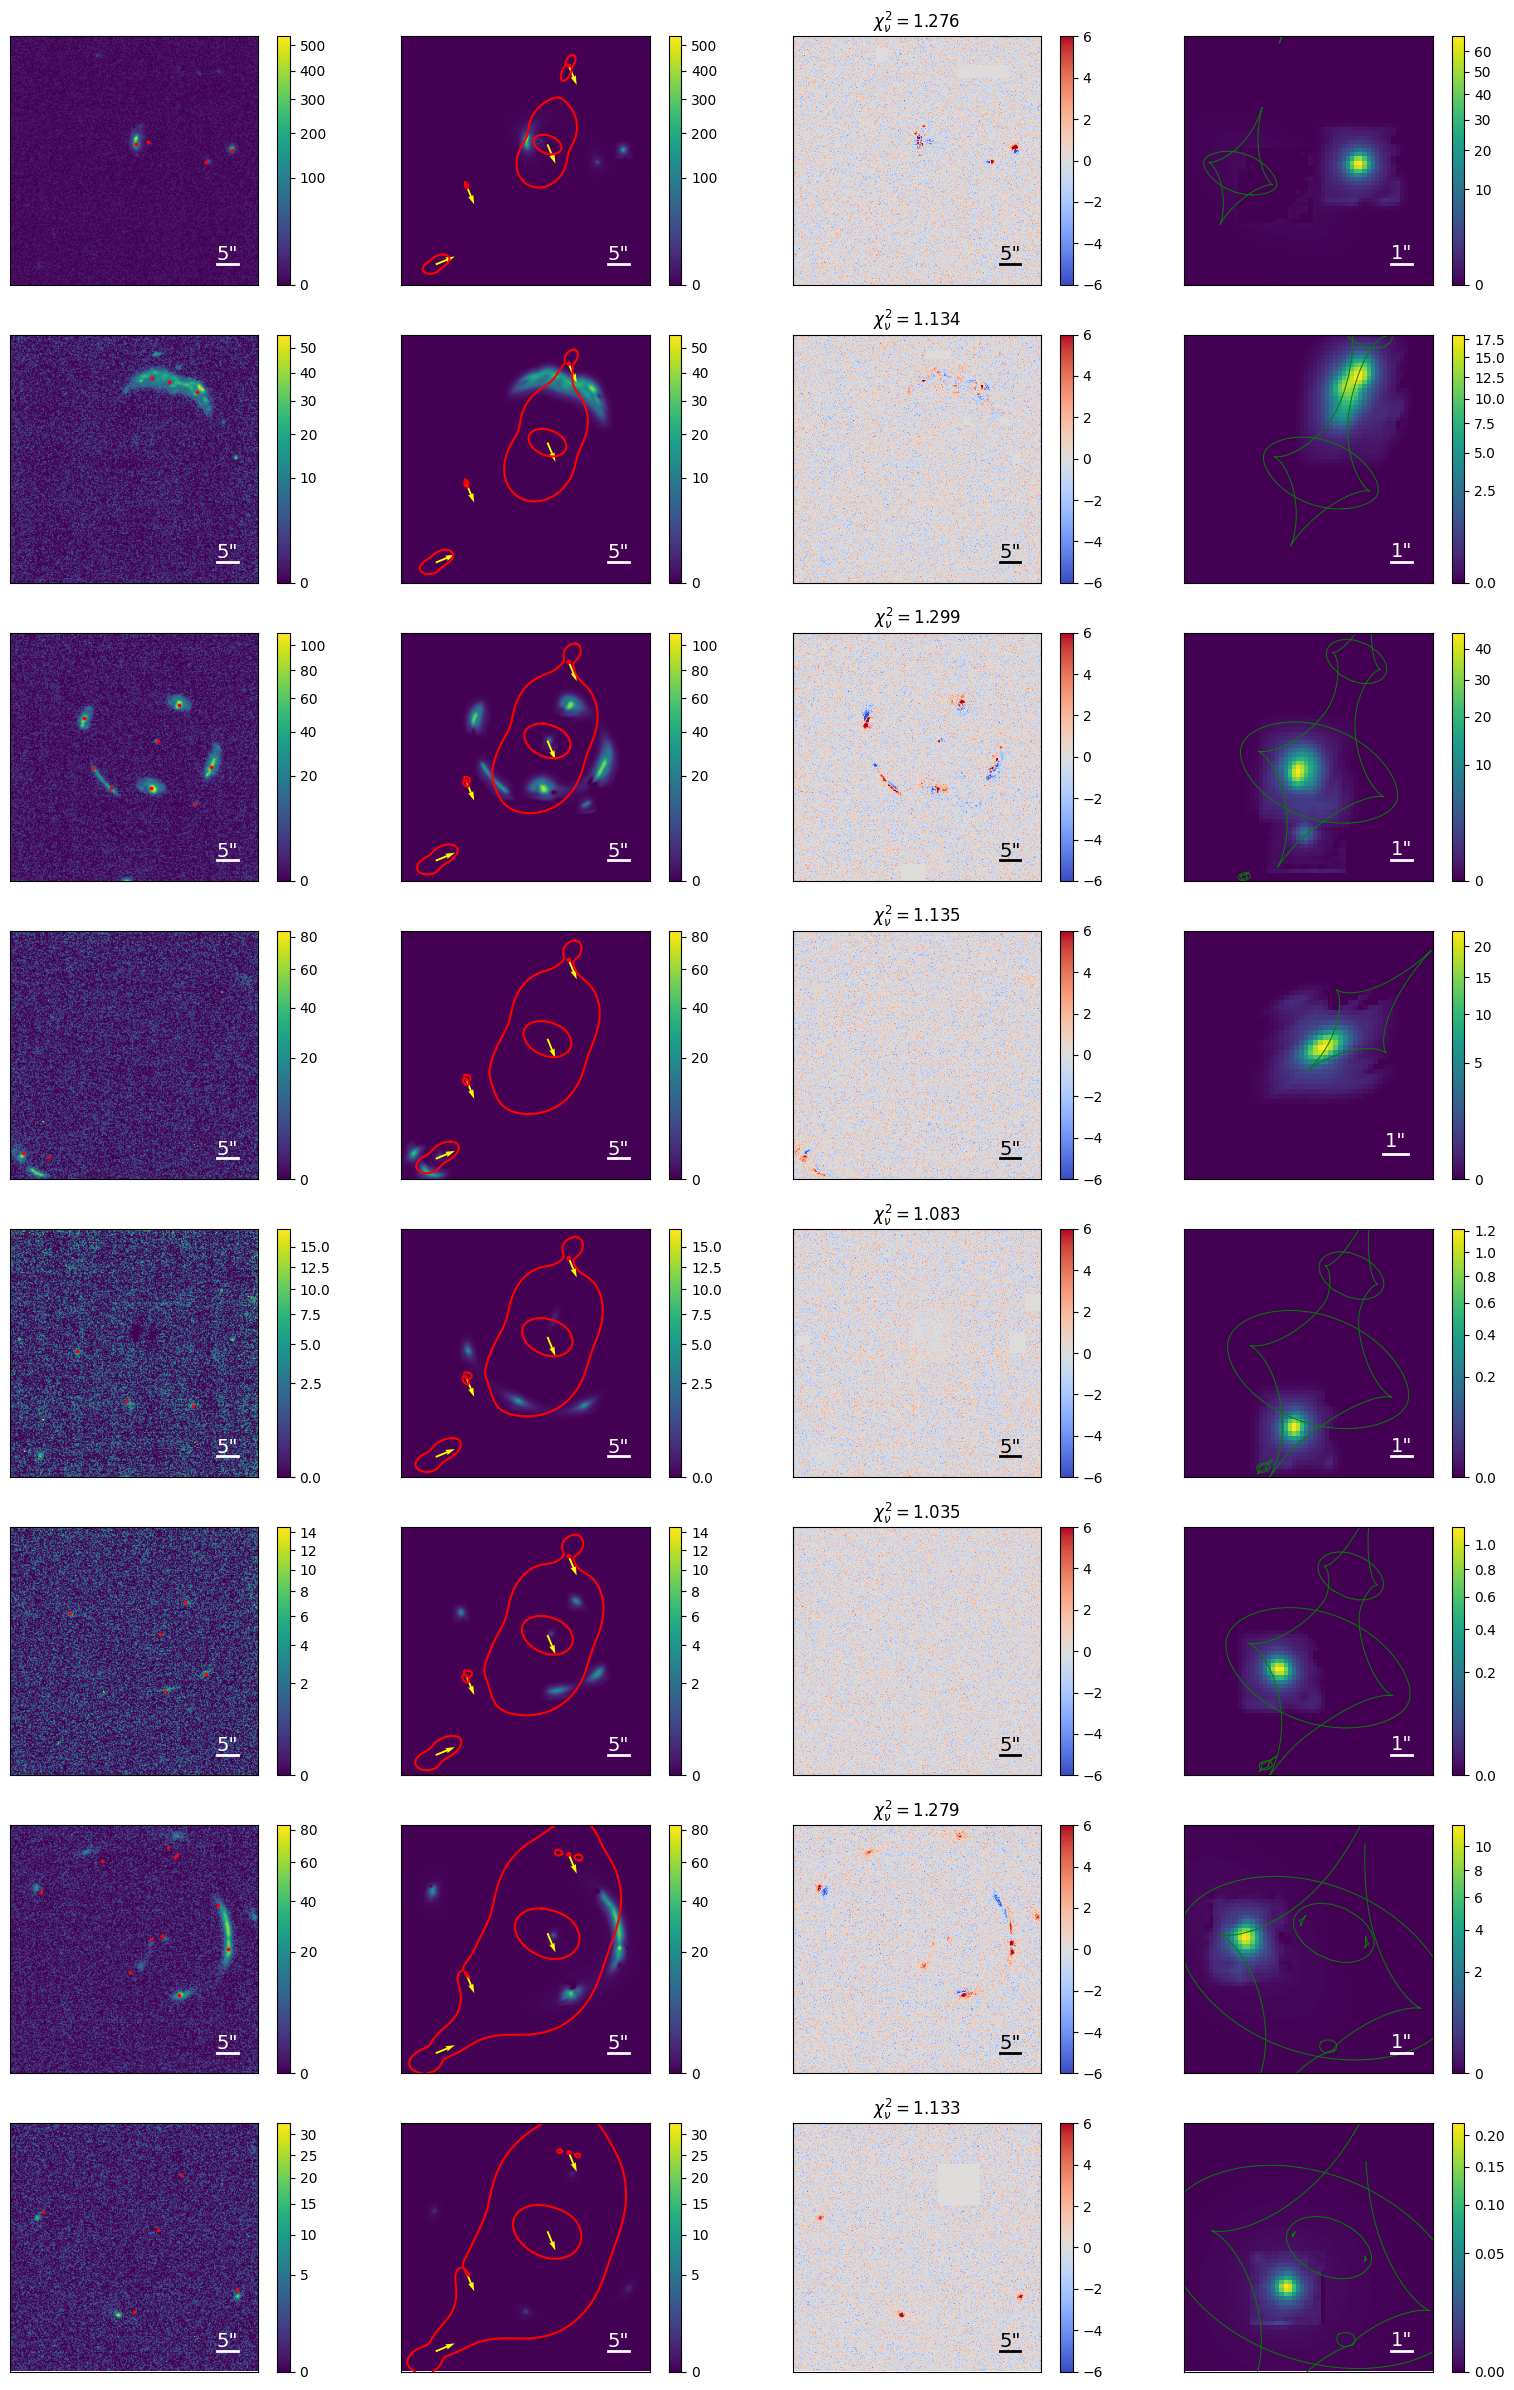

In [19]:
from astropy.visualization import simple_norm
fig, ax = plt.subplots(len(simulateds), 4, figsize=(16, 3*len(simulateds)))

for i, simulated in enumerate(simulateds): 
    observed_image = datasets[i].image
    mask = datasets[i].mask
    error_map = datasets[i].error_map

    norm = simple_norm(np.where(mask, observed_image, 0), 'sqrt', vmin=0)
    
    obs = ax[i,0].imshow(observed_image, norm=norm, origin="lower", extent=extent)
    lens_solver.plot_image_positions(ax[i,0], solver, params, planes=[i+1], size=10, styles={"extended": dict(color="red", marker=".")})
    ax[i,0].set_xlim(-1 * numPix/2*deltaPix,numPix/2*deltaPix)
    ax[i,0].set_ylim(-1 * numPix/2*deltaPix,numPix/2*deltaPix)
    scalebar(ax[i,0])
    plt.colorbar(obs, ax=ax[i,0])

    lens_solver.plot_critical_curves(ax=ax[i,1],solver=solver, params=params, color="red", plane=(i+1))
    sim = ax[i,1].imshow(simulated, norm=norm, origin="lower", extent=extent)
    plot_PAs(ax[i,1], length=5, c='yellow')
    ax[i,1].set_xlim(-1 * numPix/2*deltaPix,numPix/2*deltaPix)
    ax[i,1].set_ylim(-1 * numPix/2*deltaPix,numPix/2*deltaPix)
    scalebar(ax[i,1])
    plt.colorbar(sim, ax=ax[i,1])
    
    resid = observed_image - simulated
    res = ax[i,2].imshow(resid/error_map * mask, cmap='coolwarm', interpolation='none', vmin=-6, vmax=6, origin="lower",extent=extent)
    ax[i,2].set_title(rf'$\chi_\nu^2={np.mean((resid**2/error_map**2)[mask]):.3f}$')
    ax[i,2].set_xlim(-1 * numPix/2*deltaPix,numPix/2*deltaPix)
    ax[i,2].set_ylim(-1 * numPix/2*deltaPix,numPix/2*deltaPix)
    scalebar(ax[i,2], color='black')
    plt.colorbar(res, ax=ax[i,2])

    lens_solver.plot_caustics(ax=ax[i,3], params=params, solver=solver, color="green", plane=(i+1))
    ssim = ax[i,3].imshow(source_simulateds[i], norm=simple_norm(source_simulateds[i], 'sqrt', vmin=0), origin="lower", extent=extent)
    src_scale(ax[i,3], i)
    plt.colorbar(ssim, ax=ax[i,3])

    ax[i,0].tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    ax[i,1].tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    ax[i,2].tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    ax[i,3].tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    
plt.tight_layout()
# plt.savefig("carousel_plot.png")
plt.show()

In [20]:
datasets2 = [ImageData(np.ones((1200,1200)), 
                      SimulatorConfig(
                          delta_pix=deltaPix/4,
                          num_pix=numPix*4,
                          kernel=None,
                          supersample=1,
                          likelihood_precision='float64'),
                      mask=np.ones((1200,1200)),
                      error_map=np.ones((1200,1200)),
                      sees=sees[i]) for i in indices]

prob_model2 = ProbModel(model, datasets2, mode='lstsq')

In [21]:
unconv_sources = []
for i, simulator in enumerate(prob_model2.simulators):
    ret = np.asarray(simulator.lstsq_simulate(params, datasets2[i].image, datasets2[i].error_map, datasets2[i].mask, return_stacked=True, no_deflection=True))
    source_simulated = jnp.squeeze(jnp.sum(ret * coeffs_list[i][:, jnp.newaxis, jnp.newaxis, :], axis=-1))

    unconv_sources.append(source_simulated)

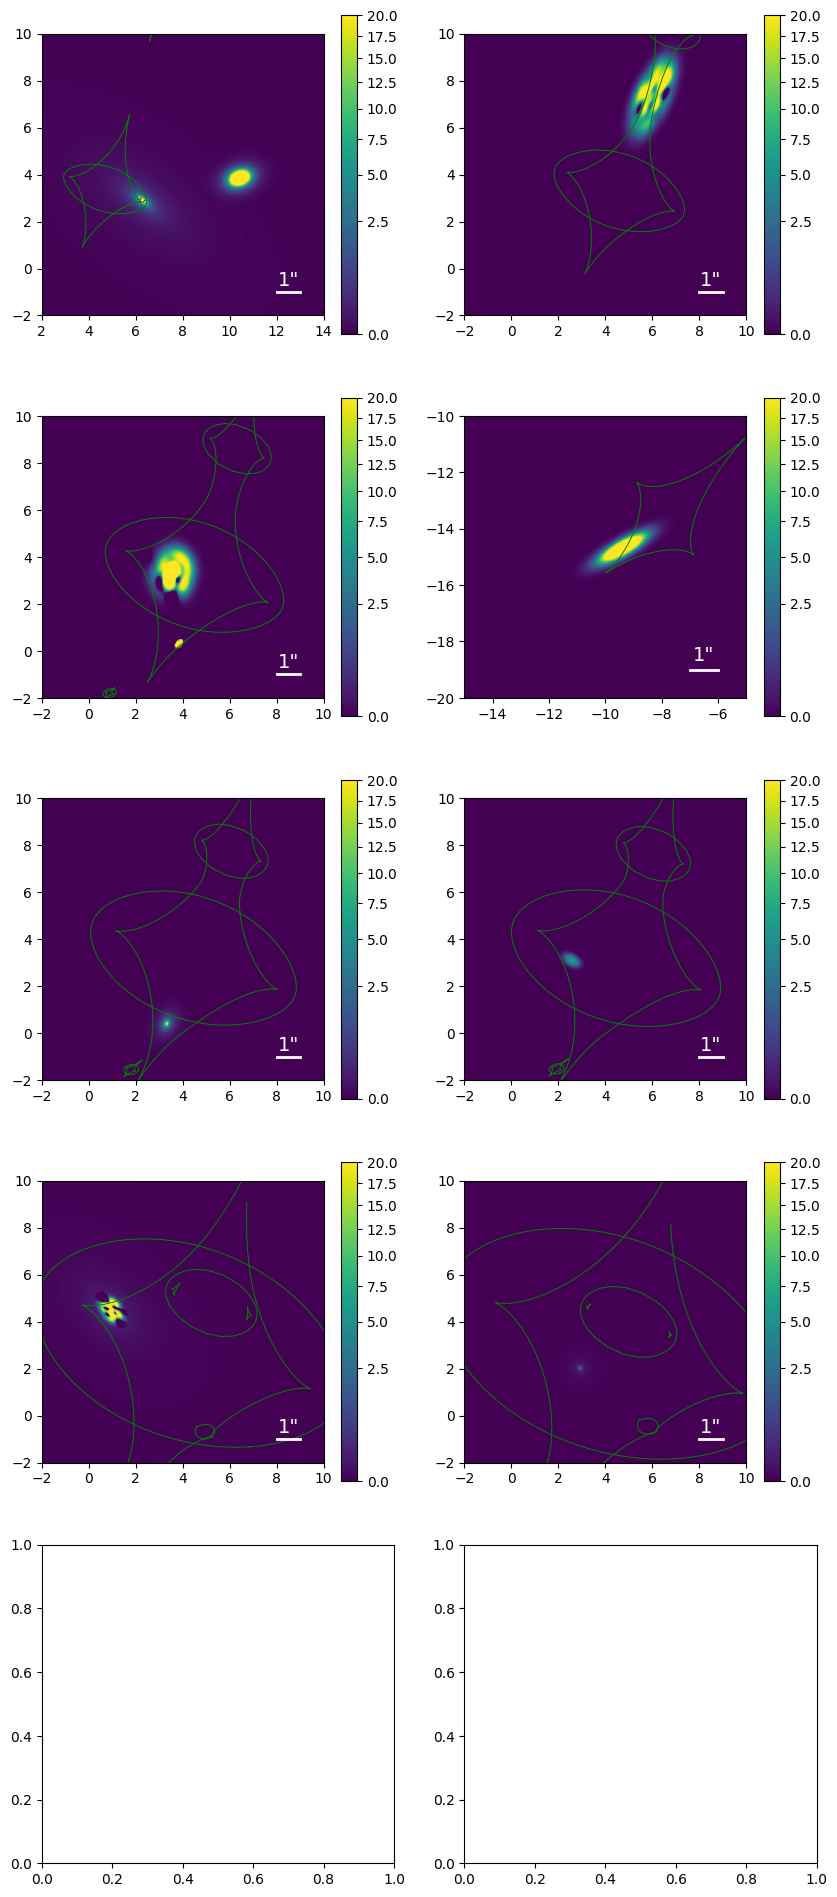

In [22]:
from astropy.visualization import simple_norm
fig, ax = plt.subplots(len(unconv_sources)//2+1,2,figsize=(10,6*len(unconv_sources)//2))
for i in range(len(unconv_sources)):
    b = ax[i//2,i%2].imshow(unconv_sources[i], norm=simple_norm(unconv_sources[i], 'sqrt', vmin=0, vmax=20), origin="lower", extent=extent)
    lens_solver.plot_caustics(ax=ax[i//2,i%2], params=params, solver=solver, color="green", plane=(i+1))
    src_scale(ax[i//2,i%2], i)
    # if i == 2:
    #     ax[i//2,i%2].set_ylim(-1,1)
    #     ax[i//2,i%2].set_xlim(3,5)
    fig.colorbar(b, ax=ax[i//2,i%2])

In [12]:
smp = np.transpose(samples, (1,0,2))
smp_physical = prob_model.bij.forward(samples)
# smp_physical = model.to_params(smp_physical)
# tups = [(0, 'mass', 0), (0, 'mass', 1), (0, 'mass', 2), (0, 'mass', 3), (0, 'mass', 4), (1, 'light', 0), (2, 'light', 0), (3, 'light', 0), (4, 'light', 0), (5, 'light', 0)]
smp_physical = jax.tree.map(lambda x: (np.squeeze(np.array(x, dtype=np.float64))), smp_physical)
plt_samples = np.vstack(
    [jnp.array(list(smp_physical.values()))]
).T
# label_prefixes = ["halo_", "Ld_", "Le_", "Lf_", "shear_", "S1&2_", "S3_", "S4&5_", "S9_", "S12&13"]
labels = []
labels.extend((key for key in smp_physical.keys()))
plt_samples = plt_samples.reshape(num_chains * num_samples,num_params)

In [13]:
labels

['planes/0/mass/0/Rs',
 'planes/0/mass/0/center_x',
 'planes/0/mass/0/center_y',
 'planes/0/mass/0/e1',
 'planes/0/mass/0/e2',
 'planes/0/mass/0/theta_E',
 'planes/0/mass/1/center_x',
 'planes/0/mass/1/center_y',
 'planes/0/mass/1/e1',
 'planes/0/mass/1/e2',
 'planes/0/mass/1/r_cut',
 'planes/0/mass/1/theta_E',
 'planes/0/mass/2/center_x',
 'planes/0/mass/2/center_y',
 'planes/0/mass/2/e1',
 'planes/0/mass/2/e2',
 'planes/0/mass/2/gamma',
 'planes/0/mass/2/theta_E',
 'planes/0/mass/3/center_x',
 'planes/0/mass/3/center_y',
 'planes/0/mass/3/e1',
 'planes/0/mass/3/e2',
 'planes/0/mass/3/r_cut',
 'planes/0/mass/3/theta_E',
 'planes/0/mass/4/gamma1',
 'planes/0/mass/4/gamma2',
 'planes/1/light/0/beta',
 'planes/1/light/0/center_x',
 'planes/1/light/0/center_y',
 'planes/1/light/0/e1',
 'planes/1/light/0/e2',
 'planes/1/light/1/R_sersic',
 'planes/1/light/1/center_x',
 'planes/1/light/1/center_y',
 'planes/1/light/1/e1',
 'planes/1/light/1/e2',
 'planes/1/light/1/n_sersic',
 'planes/2/ligh

In [ ]:
import corner
_ = corner.corner(plt_samples, show_titles=True, labels=labels, title_fmt=".3f")
#corner.corner(svi_samples, fig=_, color='red')
plt.savefig("cornerplot_mclmc")
plt.close()

In [ ]:
from scipy.optimize import root_scalar
from gigalens.jax.profiles.mass.nfw_mod import NFW_ELLIPSE

# Initialize the lens profile
nfw_profile = NFW_ELLIPSE()

def calculate_einstein_radius(Rs, alpha_Rs, e1, e2, center_x=0.0, center_y=0.0, circular_equivalent=True):
    """
    Numerically solves for the Einstein radius of an NFW profile, correctly 
    handling spherical area-equivalents.
    """
    # Calculate the native axis ratio 'q' from ellipticity parameters
    c_ell = np.sqrt(e1**2 + e2**2)
    c_ell = np.minimum(c_ell, 0.9999)
    q = (1.0 - c_ell) / (1.0 + c_ell)
    
    if circular_equivalent:
        # 1. Compute the area-preserving spherical equivalent scaling factor
        f_sph = np.sqrt((1.0 + q**2) / (2.0 * q))
        
        # 2. Scale parameters to preserve central density rho0
        eval_Rs = Rs * f_sph
        eval_alpha_Rs = alpha_Rs * (f_sph**2)
        eval_e1, eval_e2 = 0.0, 0.0
    else:
        # WARNING: Probing along the x-axis for an elliptical lens only yields
        # a valid critical curve crossing if the profile is unrotated (e2=0, e1>0).
        phi = np.arctan2(e2, e1) / 2.0
        if not np.isclose(phi, 0.0) and not np.isclose(phi, np.pi):
            print(f"Warning: Probing an elliptical profile along the x-axis with phi={phi:.2f} "
                  f"does not solve the vector lens equation accurately.")
        eval_Rs = Rs
        eval_alpha_Rs = alpha_Rs
        eval_e1, eval_e2 = e1, e2

    def objective(r):
        x_probe = center_x + r
        y_probe = center_y
        
        alpha_x, alpha_y = nfw_profile.deriv(
            x=x_probe, 
            y=y_probe, 
            Rs=eval_Rs, 
            alpha_Rs=eval_alpha_Rs, 
            e1=eval_e1, 
            e2=eval_e2, 
            center_x=center_x, 
            center_y=center_y
        )
        
        alpha_mag = jnp.sqrt(alpha_x**2 + alpha_y**2)
        return float(alpha_mag - r)

    try:
        result = root_scalar(objective, bracket=[1e-4, 100.0], method='brentq')
        if result.converged:
            return result.root
        else:
            raise ValueError("Root finding failed to converge.")
    except ValueError as e:
        print(f"Failed to find Einstein radius. Error: {e}")
        return jnp.nan

In [ ]:
from gigalens.jax.profiles.mass.nfw_mod import NFW
ratio = kwargs_lens[0]['theta_E'] / kwargs_lens[0]['Rs']
coeff = ratio * (1 - np.log(2)) / NFW().g_(ratio)

In [ ]:
kwargs_lens[0]['alpha_Rs'] = float(kwargs_lens[0].pop('theta_E') * coeff)

In [ ]:
kwargs_lens[0]

In [ ]:
theta_E = calculate_einstein_radius(circular_equivalent = True, **kwargs_lens[0])
print(theta_E)

In [ ]:
import astropy.units as u
import astropy.constants as const
from astropy.cosmology import FlatLambdaCDM

def calculate_circular_equivalent_nfw_properties(Rs, alpha_Rs, e1, e2, zl, zs, gamma1, gamma2, H0=70, Om0=0.3):
    """
    Converts elliptical NFW lensing parameters to their area-preserving circular 
    equivalents, then solves for the physical parameters c, M200, and R200.
    
    Parameters:
    -----------
    Rs : float
        Scale radius from the elliptical coordinate system (arcseconds)
    alpha_Rs : float
        Deflection angle scaling parameter (arcseconds)
    e1, e2 : float
        Ellipticity components used in the GIGALens profile framework
    zl : float
        Lens redshift
    zs : float
        Source redshift
    """
    # 0. Calculate shear stuff
    total_shear = np.sqrt(gamma1**2 + gamma2**2)
    shear_angle = 0.5 * np.arctan2(gamma2, gamma1)
    
    # 1. Compute the axis ratio 'q' from ellipticity parameters
    phi = jnp.arctan2(e2, e1) / 2
    c_ell = np.sqrt(e1**2 + e2**2)
    c_ell = np.minimum(c_ell, 0.9999)  # Avoid divide-by-zero at extreme ellipticity
    q = (1.0 - c_ell) / (1.0 + c_ell)
    
    # 2. Compute the area-preserving circular equivalent scaling factor
    f_sph = np.sqrt((1.0 + q**2) / (2.0 * q))
    
    # 3. Transform to area-preserving spherical equivalent lensing parameters
    # This keeps the characteristic central density parameter (rho0) invariant
    Rs_sph = Rs * f_sph
    alpha_Rs_sph = alpha_Rs * (f_sph**2)

    theta_E = calculate_einstein_radius(circular_equivalent = True, **kwargs_lens[0])
    
    # 4. Initialize Cosmology
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    Dl = cosmo.angular_diameter_distance(zl)
    Ds = cosmo.angular_diameter_distance(zs)
    Dls = cosmo.angular_diameter_distance_z1z2(zl, zs)
    
    # 5. Critical Surface Mass Density
    sigma_crit_prefix = (const.c**2) / (4 * np.pi * const.G)
    Sigma_crit = (sigma_crit_prefix * Ds / (Dl * Dls)).to(u.Msun / u.kpc**2)
    
    # Critical density of the Universe at lens redshift zl
    rho_crit_z = cosmo.critical_density(zl).to(u.Msun / u.kpc**3)
    
    # 6. Convert the circularized angular scale radius to a physical scale radius (kpc)
    Rs_sph_rad = (Rs_sph * u.arcsec).to(u.rad).value
    r_s_sph = (Rs_sph_rad * Dl).to(u.kpc)
    
    # 7. Compute Characteristic Physical Central Density rho_s
    # Units automatically resolve to Msun / kpc^3
    rho_s = (alpha_Rs_sph / Rs_sph) * Sigma_crit / (4 * r_s_sph * (1.0 - np.log(2.0)))
    
    # 8. Solve numerically for concentration parameter 'c'
    target_y = (3.0 * rho_s) / (200.0 * rho_crit_z)
    target_y = target_y.to(u.dimensionless_unscaled).value
    
    def concentration_objective(c):
        return (c**3) / (np.log(1.0 + c) - (c / (1.0 + c))) - target_y
    
    sol = root_scalar(concentration_objective, bracket=[1e-2, 150.0], method='brentq')
    c_param = sol.root
    
    # 9. Compute physical R200 and M200 from the circularized scale radius
    R200 = c_param * r_s_sph
    M200 = 200.0 * rho_crit_z * (4.0 * np.pi / 3.0) * (R200**3)

    # Output summary
    print(f"--- Circular Equivalent Physical Properties ---")
    print(f"Shear Magnitude            : {total_shear:.4f}")
    print(f"Shear Angle                : {shear_angle:.4f}")
    print(f"Axis Ratio (q)             : {q:.4f}")
    print(f"Position Angle (phi)       : {phi:.4f}")
    print(f"Spherical rs (r_s_sph)     : {r_s_sph.to(u.kpc):.2f}")
    print(f"Einstein Radius (theta_E)  : {theta_E:.2f}")
    print(f"Concentration (c)          : {c_param:.3f}")
    print(f"Virial Radius (R200)       : {R200.to(u.Mpc):.3f}")
    print(f"Virial Mass (M200)         : {M200.to(u.Msun):.3e}")
    
    return c_param, M200, R200

In [ ]:
c_param, M200, R200 = calculate_circular_equivalent_nfw_properties(
        Rs = kwargs_lens[0]['Rs'],
        alpha_Rs= kwargs_lens[0]['alpha_Rs'], 
        e1=kwargs_lens[0]['e1'], 
        e2=kwargs_lens[0]['e2'], 
        zl=0.49, 
        zs=1.432,
        gamma1=kwargs_lens[len(kwargs_lens) - 1]['gamma1'],
        gamma2=kwargs_lens[len(kwargs_lens) - 1]['gamma2']
    )

In [ ]:
image_positions[2]

In [ ]:
Rs = kwargs_lens[0]['Rs']
alpha_Rs = kwargs_lens[0]['alpha_Rs']
r_central_image = np.sqrt( (image_positions[2][0,2] - kwargs_lens[0]['center_x'])**2 + (image_positions[2][1,2] - kwargs_lens[0]['center_y'])**2 )

from scipy.special import gamma as gfunc
r = jnp.logspace(-3, 3, 1000) 
x = r / Rs

# NFW
rho0 = alpha_Rs / (4.0 * Rs ** 2 * (1.0 - jnp.log(2.0)))
rho_nfw = rho0 / (x * (1.0 + x)**2)

# EPL's
def rho_epl(r, gamma, theta_E):
    normalization = (3 - gamma) / 2 * gfunc(gamma/2) / (np.sqrt(np.pi) * gfunc((gamma - 1)/2)) * theta_E**(gamma-1)
    return normalization / r**gamma
x = r / theta_E
norm = rho0 / (theta_E / Rs * (1.0 + theta_E / Rs)**2)
# rho_iso = rho_epl(r, 2, 27)
rho_45 = rho_epl(r, 1.20, 13.87)
rho_3459 = rho_epl(r, 1.56, 12.86)

plt.figure(figsize=(10, 10))
plt.loglog(r, rho_nfw, label=rf'NFW, $\theta_E = {theta_E:.2f}$', lw=4, zorder=4)
# plt.loglog(r, rho_iso, label=rf'Isothermal (estimated)', lw=2, zorder=3, alpha=0.5)
plt.loglog(r, rho_45, label=rf'EPL $\gamma = 1.2, \theta_E = 13.87$', lw=2, zorder=2, alpha=0.5)
plt.loglog(r, rho_3459, label=rf'EPL $\gamma = 1.5, \theta_E = 12.86$', lw=2, zorder=1, alpha=0.5)
plt.axvline(Rs, color='gray', linestyle='--', label=r'Scale Radius $R_s$')
plt.axvline(theta_E, color='black', linestyle='--', label=r'NFW Einstein Radius $\theta_E$')
plt.axvline(r_central_image, color='red', linestyle='--', label=r'Source 4 Central Image')

plt.xlabel(r'Radius $r$ (arcsec)', fontsize=12)
plt.ylabel(r'3D Mass Density $\rho(r)$', fontsize=12)
plt.title('NFW 3D Mass Density Profile', fontsize=13)
plt.legend()
plt.grid(True, which="major", ls="--", alpha=0.5)
plt.show()